In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.pipeline import Pipeline
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from scipy.stats import skew, kurtosis
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Define paths - only using the provided training directories
REAL_PATH = "/kaggle/input/real-and-fake-face-detection/real_and_fake_face/training_real"
FAKE_PATH = "/kaggle/input/real-and-fake-face-detection/real_and_fake_face/training_fake"

def load_images_from_folder(folder, label, max_images=None):
    """Load images from a folder with a specific label"""
    images = []
    labels = []
    paths = []
    
    filenames = os.listdir(folder)
    if max_images:
        filenames = filenames[:max_images]
    
    for filename in tqdm(filenames):
        img_path = os.path.join(folder, filename)
        try:
            img = cv2.imread(img_path)
            if img is not None:
                # Resize all images to a standard size to reduce memory usage
                img = cv2.resize(img, (256, 256))
                images.append(img)
                labels.append(label)
                paths.append(img_path)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    return images, labels, paths

# Load real images (label 0)
print("Loading real images...")
real_images, real_labels, real_paths = load_images_from_folder(REAL_PATH, 0)

# Load fake images (label 1)
print("Loading fake images...")
fake_images, fake_labels, fake_paths = load_images_from_folder(FAKE_PATH, 1)

# Combine datasets
images = real_images + fake_images
labels = real_labels + fake_labels
paths = real_paths + fake_paths

print(f"Loaded {len(real_images)} real images and {len(fake_images)} fake images")



Loading real images...


100%|██████████| 1081/1081 [00:21<00:00, 49.36it/s]


Loading fake images...


100%|██████████| 960/960 [00:17<00:00, 55.11it/s]

Loaded 1081 real images and 960 fake images


In [3]:
# Function to extract texture features using LBP
def extract_lbp_features(img, num_points=24, radius=8, bins=256):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, num_points, radius, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=bins, range=(0, bins))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Function to extract GLCM texture features
def extract_glcm_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Normalize the image
    gray = gray.astype(np.uint8)
    
    # Calculate GLCM
    distances = [1, 2, 3]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    
    # Calculate GLCM properties
    contrast = graycoprops(glcm, 'contrast').ravel()
    dissimilarity = graycoprops(glcm, 'dissimilarity').ravel()
    homogeneity = graycoprops(glcm, 'homogeneity').ravel()
    energy = graycoprops(glcm, 'energy').ravel()
    correlation = graycoprops(glcm, 'correlation').ravel()
    
    # Return features as a flattened array
    return np.hstack([contrast, dissimilarity, homogeneity, energy, correlation])

# Function to extract color statistics
def extract_color_features(img):
    features = []
    
    # Convert to different color spaces
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    
    # Extract statistics for each channel in each color space
    for color_space in [img, hsv, ycrcb, lab]:
        for i in range(3):
            channel = color_space[:,:,i].flatten()
            features.extend([
                np.mean(channel),
                np.std(channel),
                skew(channel),
                kurtosis(channel),
                np.percentile(channel, 10),
                np.percentile(channel, 90),
                np.max(channel) - np.min(channel)
            ])
    
    return np.array(features)

# Function to extract facial features using OpenCV's Haar Cascade
def extract_opencv_face_features(img):
    # Load OpenCV's pre-trained face detector
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    features = []
    
    if len(faces) > 0:
        # Get the largest face
        max_area = 0
        max_face = None
        for (x, y, w, h) in faces:
            if w*h > max_area:
                max_area = w*h
                max_face = (x, y, w, h)
        
        x, y, w, h = max_face
        face_roi = gray[y:y+h, x:x+w]
        
        # Face region properties
        features.extend([
            w/img.shape[1],  # face width relative to image
            h/img.shape[0],  # face height relative to image
            w/h,             # face aspect ratio
            x/img.shape[1],  # face x position
            y/img.shape[0],  # face y position
        ])
        
        # Detect eyes in the face region
        eyes = eye_cascade.detectMultiScale(face_roi)
        
        if len(eyes) >= 2:
            # Sort eyes by x-coordinate
            eyes = sorted(eyes, key=lambda e: e[0])
            
            # Extract features from the first two eyes
            for i in range(min(2, len(eyes))):
                ex, ey, ew, eh = eyes[i]
                features.extend([
                    (x+ex)/img.shape[1],  # eye x position
                    (y+ey)/img.shape[0],  # eye y position
                    ew/w,                 # eye width relative to face
                    eh/h,                 # eye height relative to face
                ])
                
            if len(eyes) >= 2:
                # Calculate distance between eyes
                eye1_center = (eyes[0][0] + eyes[0][2]/2, eyes[0][1] + eyes[0][3]/2)
                eye2_center = (eyes[1][0] + eyes[1][2]/2, eyes[1][1] + eyes[1][3]/2)
                eye_distance = np.sqrt((eye1_center[0] - eye2_center[0])**2 + 
                                      (eye1_center[1] - eye2_center[1])**2)
                features.append(eye_distance/w)  # eye distance relative to face width
        
        # Fill with zeros if missing eyes
        while len(features) < 14:  # 5 face features + 4 features per eye + 1 eye distance
            features.append(0)
    else:
        # No face detected, fill with zeros
        features = [0] * 14
    
    return np.array(features)

# Function to extract frequency domain features
def extract_frequency_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply FFT
    f_transform = np.fft.fft2(gray)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1e-10)
    
    # Divide the spectrum into rings (low, mid, high frequencies)
    h, w = magnitude_spectrum.shape
    center_y, center_x = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    
    # Define frequency rings
    low_freq_mask = dist_from_center <= min(h, w) / 6
    mid_freq_mask = (dist_from_center > min(h, w) / 6) & (dist_from_center <= min(h, w) / 3)
    high_freq_mask = dist_from_center > min(h, w) / 3
    
    # Extract features from the rings
    low_freq_features = magnitude_spectrum[low_freq_mask]
    mid_freq_features = magnitude_spectrum[mid_freq_mask]
    high_freq_features = magnitude_spectrum[high_freq_mask]
    
    # Statistical features for each frequency band
    features = []
    for freq_band in [low_freq_features, mid_freq_features, high_freq_features]:
        features.extend([
            np.mean(freq_band),
            np.std(freq_band),
            skew(freq_band),
            kurtosis(freq_band)
        ])
    
    return np.array(features)

# Function to extract ELA (Error Level Analysis) features
def extract_ela_features(img, quality=90):
    # Create a temporary file to save JPEG
    temp_filename = "temp_ela.jpg"
    
    try:
        # Save the image as JPEG with specified quality
        cv2.imwrite(temp_filename, img, [cv2.IMWRITE_JPEG_QUALITY, quality])
        
        # Read the saved image
        saved_img = cv2.imread(temp_filename)
        
        # Calculate the ELA
        ela = cv2.absdiff(img, saved_img) * 10
        
        # Extract features from ELA
        features = []
        for channel in range(3):  # BGR channels
            channel_ela = ela[:,:,channel]
            features.extend([
                np.mean(channel_ela),
                np.std(channel_ela),
                np.max(channel_ela)
            ])
        
        # Remove the temporary file
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
            
        return np.array(features)
    except Exception as e:
        print(f"Error in ELA extraction: {e}")
        # If error occurs, return zeros
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
        return np.zeros(9)  # 3 features per channel × 3 channels

# Function to extract image quality metrics
def extract_quality_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Laplacian variance (sharpness)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    # Sobel gradients
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobelx**2 + sobely**2)
    
    # Noise estimation
    noise_sigma = estimate_noise(gray)
    
    features = [
        laplacian_var,
        np.mean(sobel_mag),
        np.std(sobel_mag),
        noise_sigma
    ]
    
    return np.array(features)

# Helper function for noise estimation
def estimate_noise(img):
    H, W = img.shape
    M = [[1, -2, 1],
         [-2, 4, -2],
         [1, -2, 1]]
    
    sigma = np.sum(np.sum(np.absolute(ndimage.convolve(img, M))))
    sigma = sigma * np.sqrt(0.5 * np.pi) / (6 * (W-2) * (H-2))
    
    return sigma

# Function to combine all features
def extract_all_features(img):
    lbp_features = extract_lbp_features(img)
    glcm_features = extract_glcm_features(img)
    color_features = extract_color_features(img)
    face_features = extract_opencv_face_features(img)
    freq_features = extract_frequency_features(img)
    quality_features = extract_quality_features(img)
    ela_features = extract_ela_features(img)
    
    # Combine all features
    all_features = np.concatenate([
        lbp_features, 
        glcm_features, 
        color_features, 
        face_features,
        freq_features,
        quality_features,
        ela_features
    ])
    
    return all_features

# Extract features from all images
print("Extracting features from all images...")
X = []
y = np.array(labels)

# Process all images (or limit if you have memory constraints)
for i in tqdm(range(len(images))):
    features = extract_all_features(images[i])
    X.append(features)

X = np.array(X)
print(f"Feature extraction complete. Feature shape: {X.shape}")



Extracting features from all images...


100%|██████████| 2041/2041 [10:19<00:00,  3.29it/s]

Feature extraction complete. Feature shape: (2041, 439)


Train set: (1632, 439), Test set: (409, 439)
Training the model...

Model Evaluation:
Accuracy: 0.6333

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       217
           1       0.63      0.54      0.58       192

    accuracy                           0.63       409
   macro avg       0.63      0.63      0.63       409
weighted avg       0.63      0.63      0.63       409



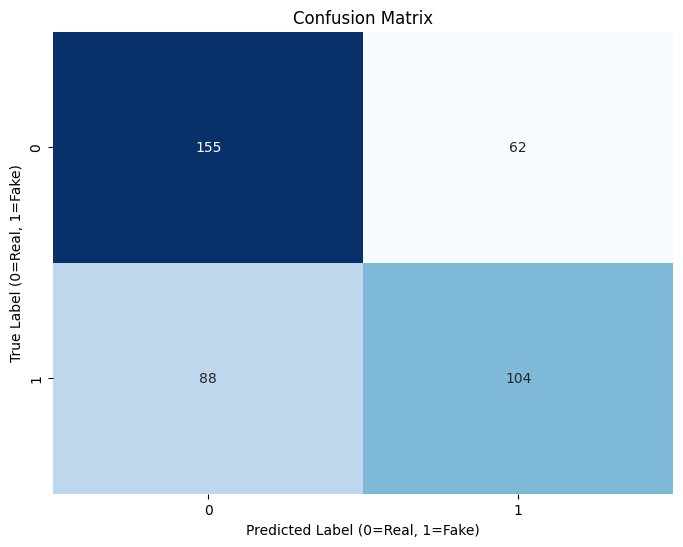

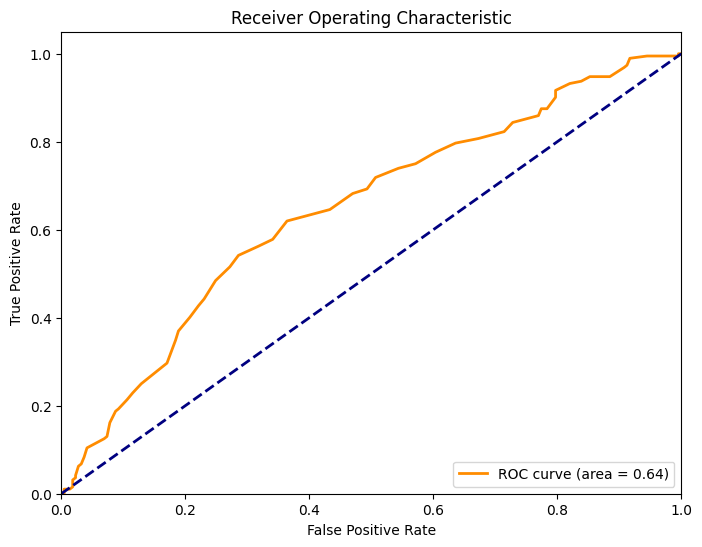

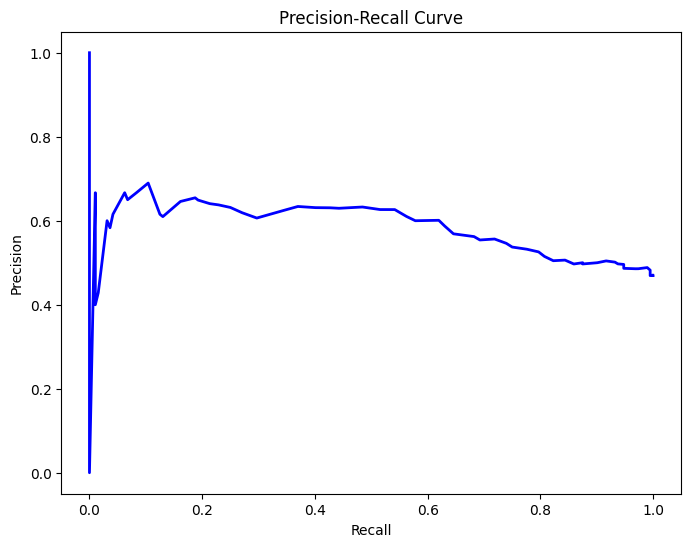


Selected 439 features out of 439

Model Evaluation with Selected Features:
Accuracy: 0.6333

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       217
           1       0.63      0.54      0.58       192

    accuracy                           0.63       409
   macro avg       0.63      0.63      0.63       409
weighted avg       0.63      0.63      0.63       409


Comparing different classifiers:

Training Random Forest...
Random Forest Accuracy: 0.6333

Training Gradient Boosting...
Gradient Boosting Accuracy: 0.6308

Training SVM...
SVM Accuracy: 0.6528


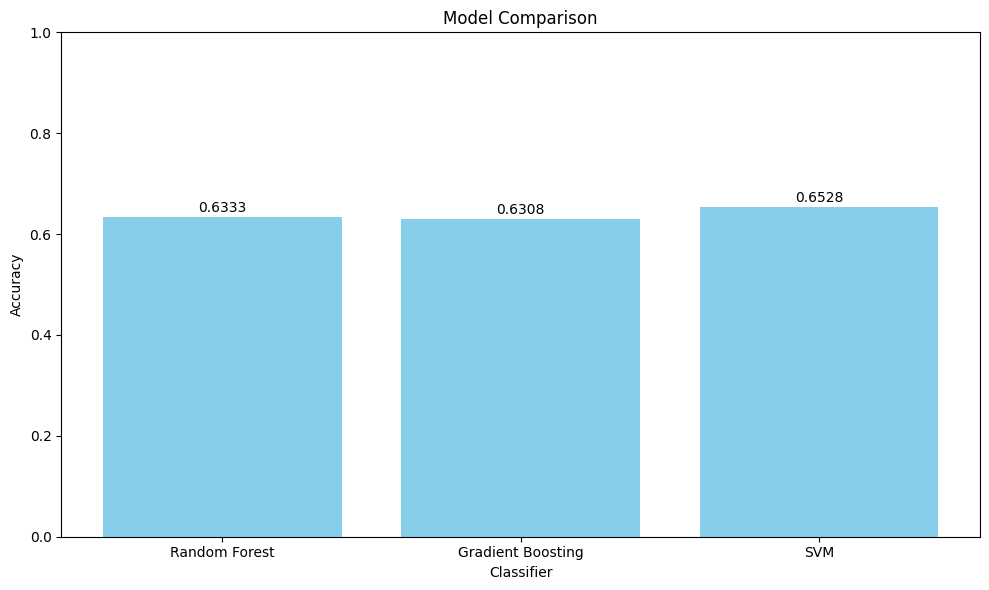

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Define classification pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
print("Training the model...")
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label (0=Real, 1=Fake)')
plt.xlabel('Predicted Label (0=Real, 1=Fake)')
plt.show()

# Plot ROC curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Feature selection to identify most important features
from sklearn.feature_selection import SelectFromModel

# Use a tree-based model for feature importance
feature_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold="median"
)

# Fit the selector on the training data
feature_selector.fit(X_train, y_train)

# Get the selected features
X_train_selected = feature_selector.transform(X_train)
X_test_selected = feature_selector.transform(X_test)

print(f"\nSelected {X_train_selected.shape[1]} features out of {X_train.shape[1]}")

# Train a model on the selected features
selected_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

selected_pipeline.fit(X_train_selected, y_train)
y_pred_selected = selected_pipeline.predict(X_test_selected)

print("\nModel Evaluation with Selected Features:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_selected):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_selected))

# Try other classifiers for comparison
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}

print("\nComparing different classifiers:")
for name, classifier in classifiers.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', classifier)
    ])
    pipeline.fit(X_train_selected, y_train)
    y_pred = pipeline.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

# Plot model comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title('Model Comparison')
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()



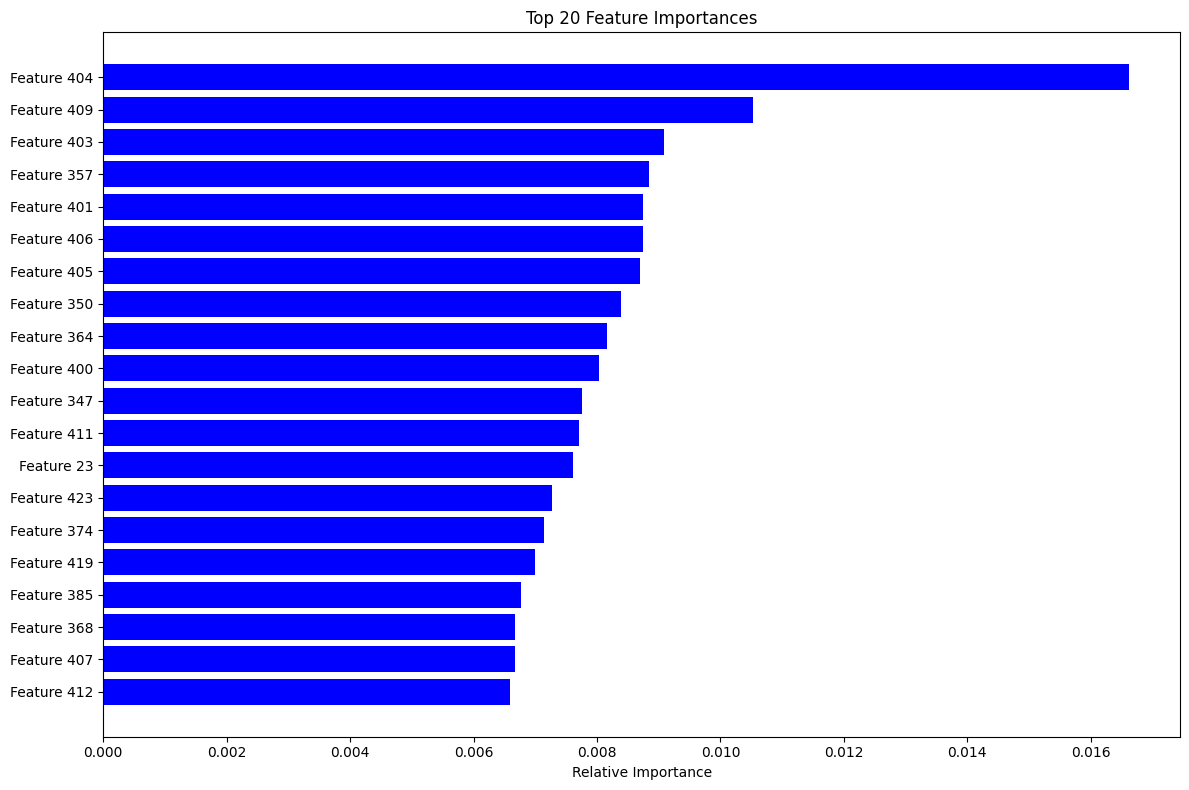

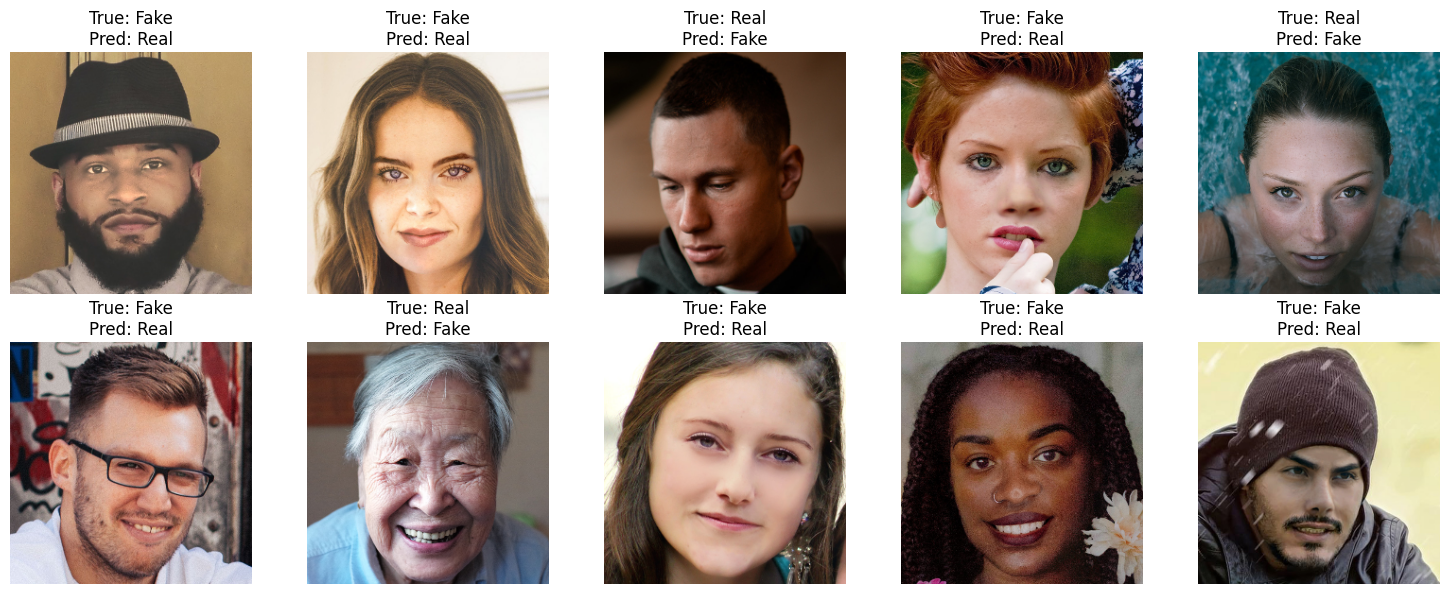

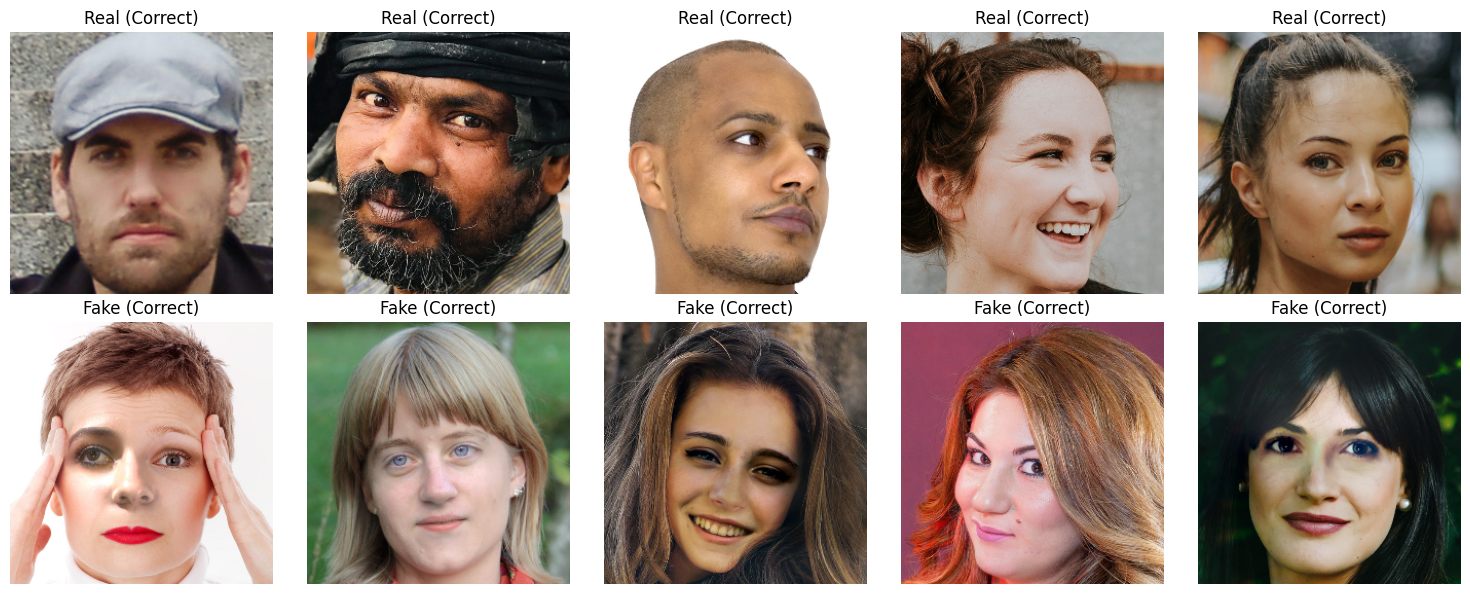

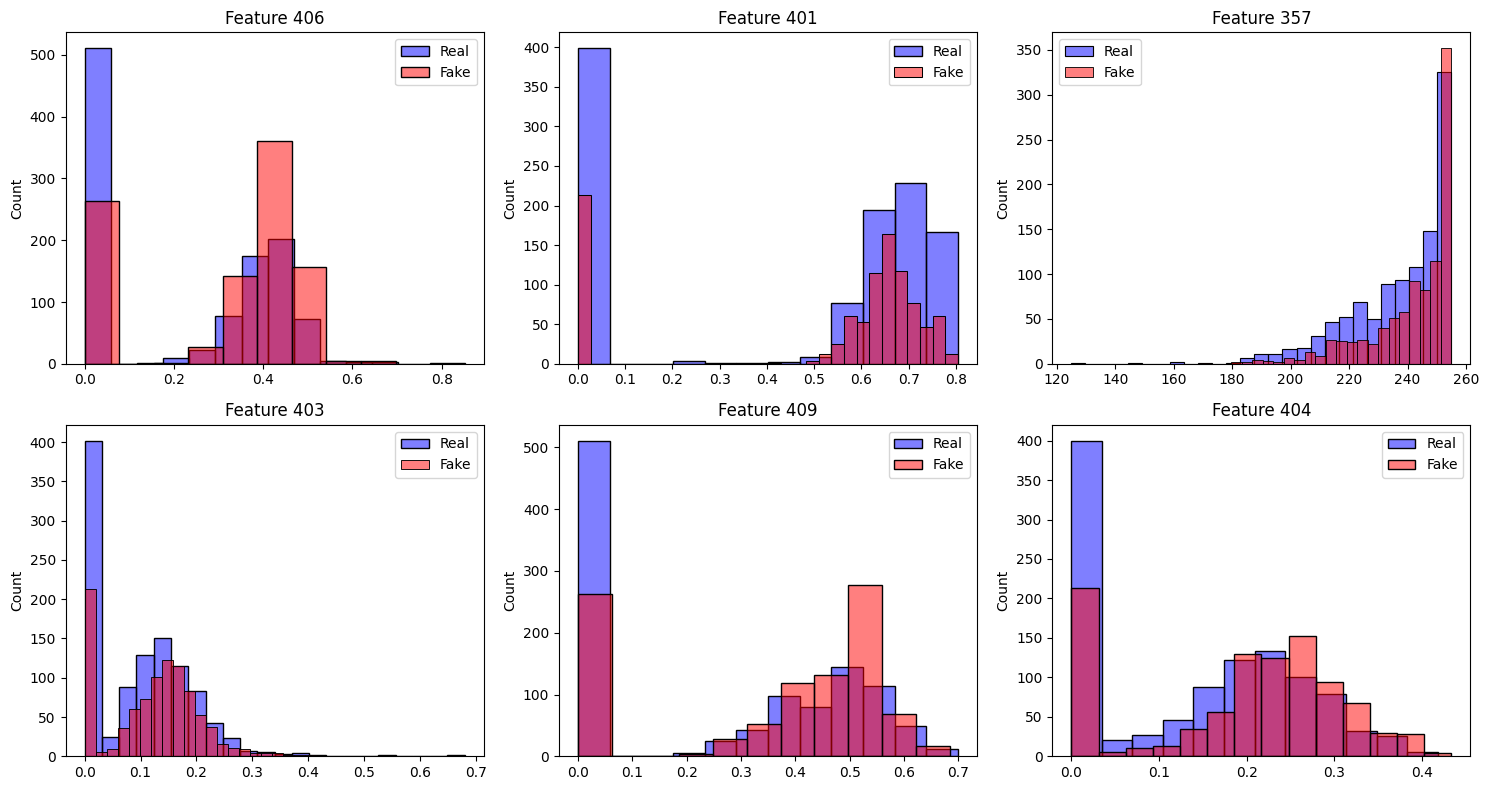

Final model saved to 'real_fake_face_detector.pkl'


In [5]:
# Function to visualize feature importance for tree-based models
def plot_feature_importance(model, feature_names=None):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[-20:]  # Get indices of top 20 features
        
        plt.figure(figsize=(12, 8))
        plt.title('Top 20 Feature Importances')
        plt.barh(range(20), importances[indices], color='b', align='center')
        if feature_names is not None:
            plt.yticks(range(20), [feature_names[i] for i in indices])
        else:
            plt.yticks(range(20), [f'Feature {i}' for i in indices])
        plt.xlabel('Relative Importance')
        plt.tight_layout()
        plt.show()

# Get the trained Random Forest classifier from the pipeline
rf_classifier = classifiers['Random Forest']
rf_classifier.fit(X_train_selected, y_train)

# Visualize feature importance
plot_feature_importance(rf_classifier)

# Function to visualize misclassified examples
def plot_misclassified_examples(X_test, y_test, y_pred, original_images, test_indices):
    misclassified_indices = np.where(y_test != y_pred)[0]
    
    if len(misclassified_indices) > 0:
        fig, axes = plt.subplots(2, min(5, len(misclassified_indices)), figsize=(15, 6))
        if len(misclassified_indices) < 5:
            axes = axes.reshape(2, -1)
        else:
            axes = axes.reshape(2, 5)
        
        for i, ax_idx in enumerate(range(min(10, len(misclassified_indices)))):
            idx = misclassified_indices[ax_idx]
            original_idx = test_indices[idx]
            ax = axes[i//5, i%5]
            ax.imshow(cv2.cvtColor(images[original_idx], cv2.COLOR_BGR2RGB))
            ax.set_title(f"True: {'Real' if y_test[idx]==0 else 'Fake'}\nPred: {'Real' if y_pred[idx]==0 else 'Fake'}")
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No misclassified examples found!")

# Get the indices of the test set in the original images array
test_indices = np.arange(len(X))
_, test_indices = train_test_split(test_indices, test_size=0.2, random_state=42, stratify=y)

# Visualize misclassified examples
plot_misclassified_examples(X_test_selected, y_test, y_pred_selected, images, test_indices)

# Visualize some examples of correctly classified images
def plot_correct_examples(X_test, y_test, y_pred, original_images, test_indices):
    correct_indices = np.where(y_test == y_pred)[0]
    
    # Get some examples of correctly classified real and fake images
    correct_real = [i for i in correct_indices if y_test[i] == 0][:5]
    correct_fake = [i for i in correct_indices if y_test[i] == 1][:5]
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # Plot correct real images
    for i, idx in enumerate(correct_real[:5]):
        ax = axes[0, i]
        original_idx = test_indices[idx]
        ax.imshow(cv2.cvtColor(images[original_idx], cv2.COLOR_BGR2RGB))
        ax.set_title(f"Real (Correct)")
        ax.axis('off')
    
    # Plot correct fake images
    for i, idx in enumerate(correct_fake[:5]):
        ax = axes[1, i]
        original_idx = test_indices[idx]
        ax.imshow(cv2.cvtColor(images[original_idx], cv2.COLOR_BGR2RGB))
        ax.set_title(f"Fake (Correct)")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize correctly classified examples
plot_correct_examples(X_test_selected, y_test, y_pred_selected, images, test_indices)

# Visualize feature distributions between real and fake images
def plot_feature_distributions(X, y, feature_idxs=None):
    if feature_idxs is None:
        # Use random features
        feature_idxs = np.random.choice(X.shape[1], min(6, X.shape[1]), replace=False)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, feat_idx in enumerate(feature_idxs[:6]):
        sns.histplot(X[y==0, feat_idx], label='Real', color='blue', alpha=0.5, ax=axes[i])
        sns.histplot(X[y==1, feat_idx], label='Fake', color='red', alpha=0.5, ax=axes[i])
        axes[i].set_title(f'Feature {feat_idx}')
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

# Get the most important features from the model
if hasattr(rf_classifier, 'feature_importances_'):
    top_features = np.argsort(rf_classifier.feature_importances_)[-6:]
    plot_feature_distributions(X, y, top_features)
    # Save the trained model

import joblib
joblib.dump(selected_pipeline, 'real_fake_face_detector.pkl')
print("Final model saved to 'real_fake_face_detector.pkl'")


Visualizing feature extraction for a real and fake image example:
Real Image Example:


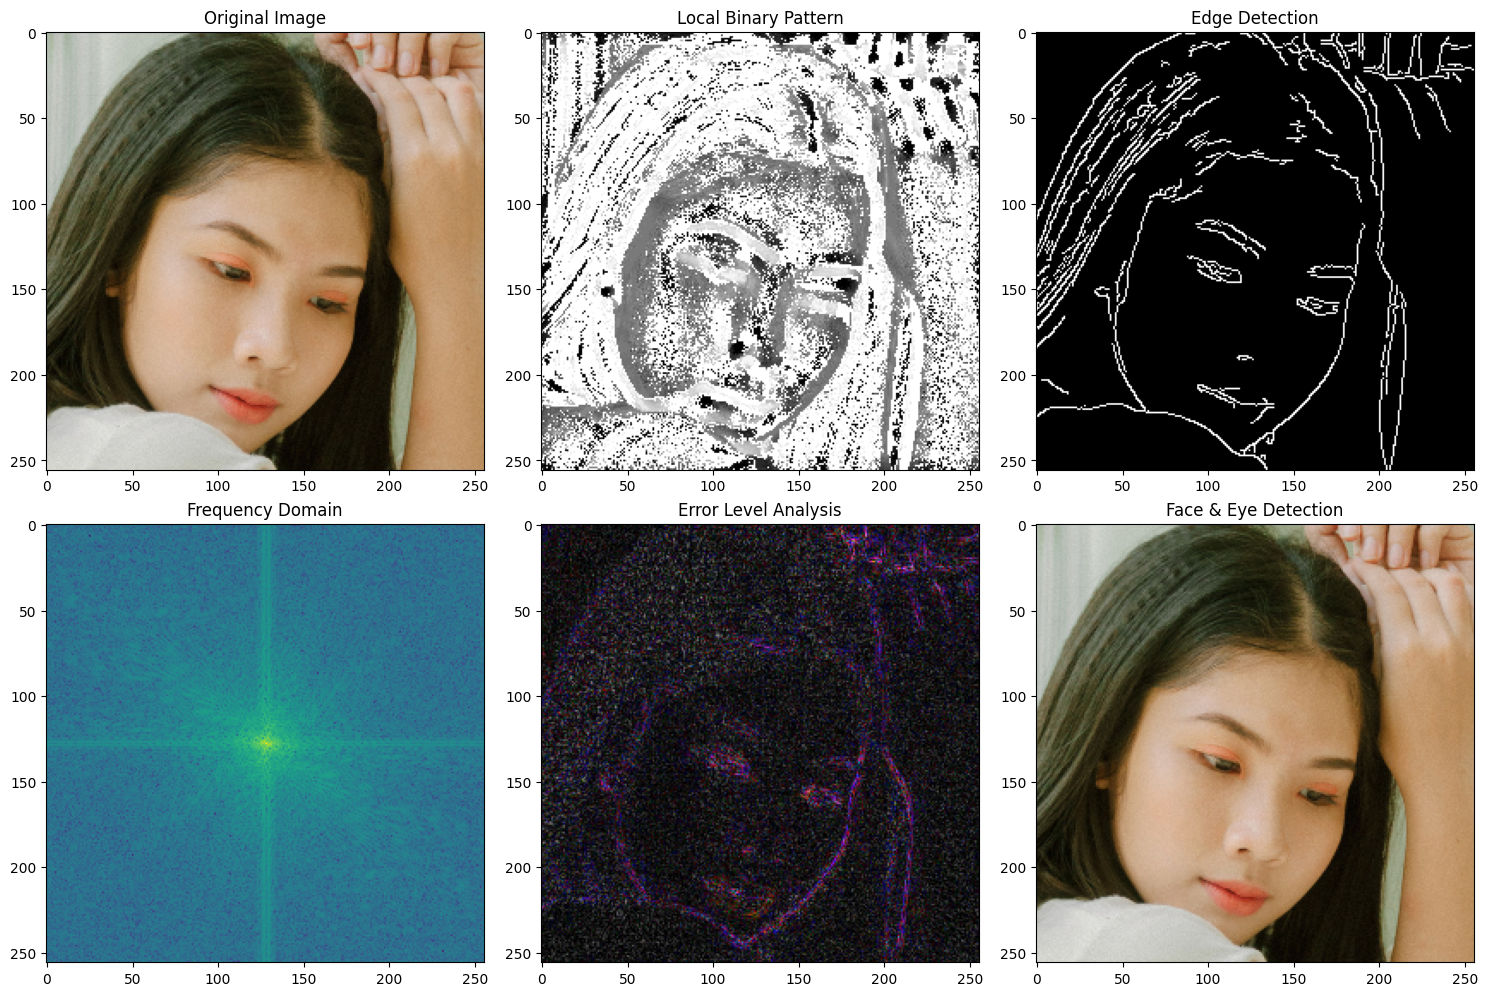

Fake Image Example:


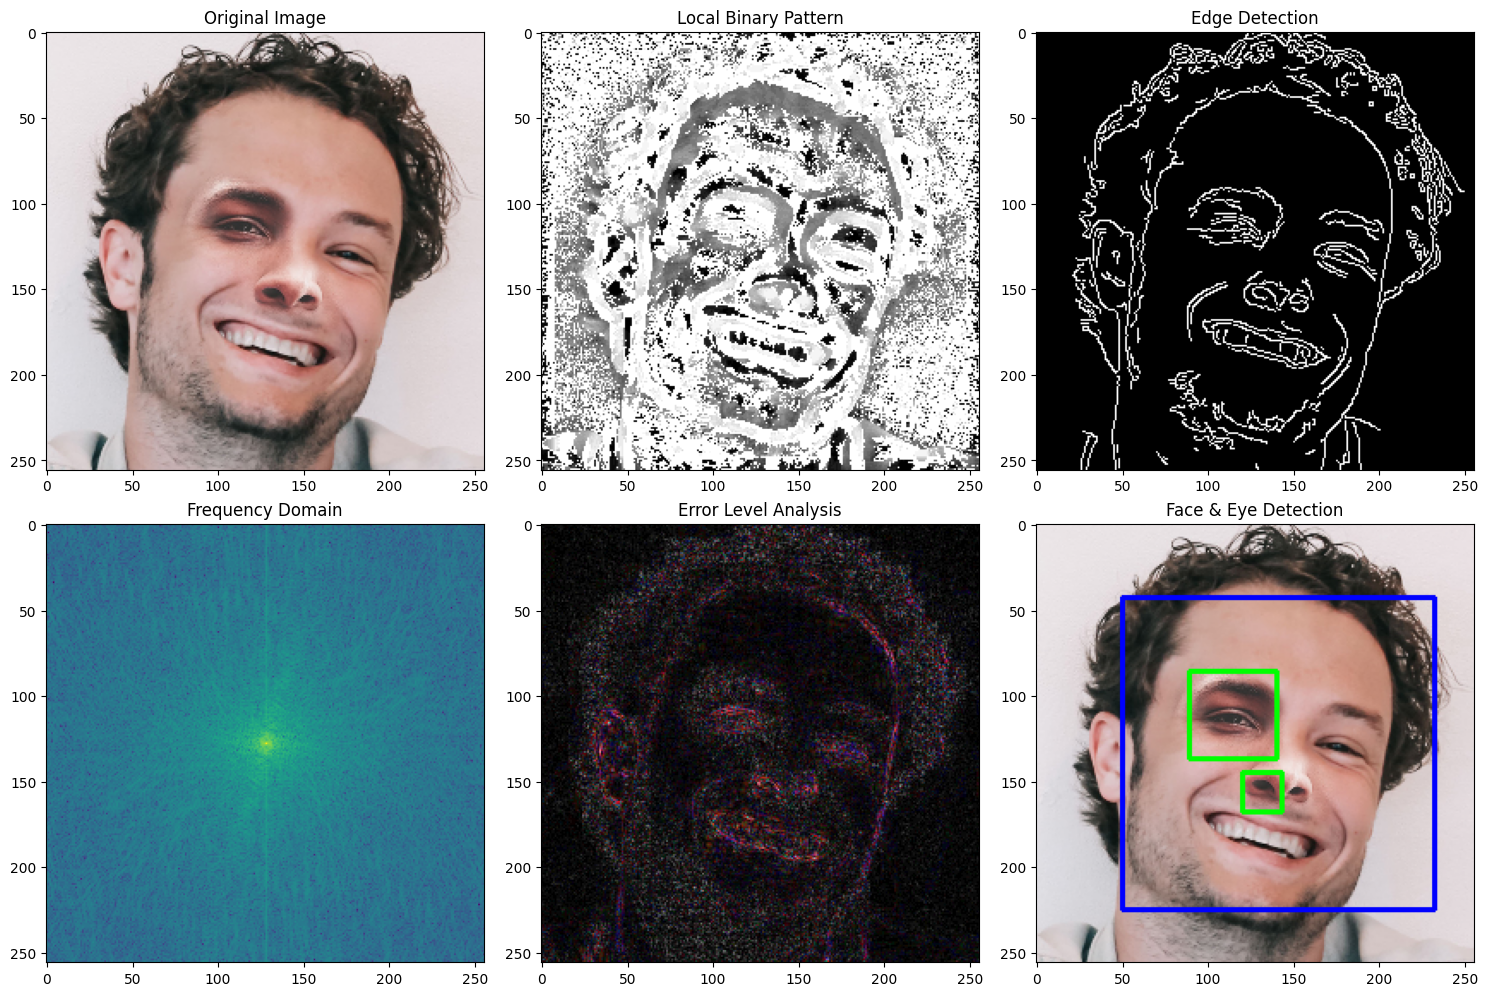


Complete! The model has been trained and evaluated.


In [6]:



# Create a function for visualizing the feature extraction process
def visualize_feature_extraction(img):
    # Original image
    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    # LBP
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, 24, 8, method="uniform")
    plt.subplot(2, 3, 2)
    plt.title("Local Binary Pattern")
    plt.imshow(lbp, cmap='gray')
    
    # Edge Detection
    edges = cv2.Canny(gray, 100, 200)
    plt.subplot(2, 3, 3)
    plt.title("Edge Detection")
    plt.imshow(edges, cmap='gray')
    
    # Frequency Domain (Magnitude Spectrum)
    f_transform = np.fft.fft2(gray)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1e-10)
    plt.subplot(2, 3, 4)
    plt.title("Frequency Domain")
    plt.imshow(magnitude_spectrum, cmap='viridis')
    
    # Error Level Analysis
    temp_filename = "temp_ela.jpg"
    cv2.imwrite(temp_filename, img, [cv2.IMWRITE_JPEG_QUALITY, 90])
    saved_img = cv2.imread(temp_filename)
    ela_visualization = cv2.absdiff(img, saved_img) * 10
    if os.path.exists(temp_filename):
        os.remove(temp_filename)
    plt.subplot(2, 3, 5)
    plt.title("Error Level Analysis")
    plt.imshow(cv2.cvtColor(ela_visualization, cv2.COLOR_BGR2RGB))
    
    # Face Detection
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    img_with_face = img.copy()
    
    for (x, y, w, h) in faces:
        cv2.rectangle(img_with_face, (x, y), (x+w, y+h), (255, 0, 0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img_with_face[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
    
    plt.subplot(2, 3, 6)
    plt.title("Face & Eye Detection")
    plt.imshow(cv2.cvtColor(img_with_face, cv2.COLOR_BGR2RGB))
    
    plt.tight_layout()
    plt.show()

# Visualize feature extraction on sample images
print("Visualizing feature extraction for a real and fake image example:")
# Get one real and one fake image
real_idx = np.random.choice(np.where(y == 0)[0])
fake_idx = np.random.choice(np.where(y == 1)[0])

print("Real Image Example:")
visualize_feature_extraction(images[real_idx])

print("Fake Image Example:")
visualize_feature_extraction(images[fake_idx])

print("\nComplete! The model has been trained and evaluated.")